C:\Users\mavan\AppData\Roaming\Python\Python314\site-packages\torchvision\models\googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Epoch [1/10], Train Acc: 93.14%, Val Acc: 97.72%, Train Loss: 0.2218, Val Loss: 0.0775


Epoch [2/10], Train Acc: 97.88%, Val Acc: 98.05%, Train Loss: 0.0765, Val Loss: 0.0704


Epoch [3/10], Train Acc: 98.36%, Val Acc: 98.72%, Train Loss: 0.0592, Val Loss: 0.0449


Epoch [4/10], Train Acc: 98.66%, Val Acc: 98.80%, Train Loss: 0.0501, Val Loss: 0.0452


...

Epoch [7/10], Train Acc: 98.97%, Val Acc: 98.78%, Train Loss: 0.0413, Val Loss: 0.0545


Epoch [8/10], Train Acc: 98.97%, Val Acc: 98.80%, Train Loss: 0.0398, Val Loss: 0.0566


Epoch [9/10], Train Acc: 99.15%, Val Acc: 97.62%, Train Loss: 0.0320, Val Loss: 0.0893


Epoch [10/10], Train Acc: 99.12%, Val Acc: 98.80%, Train Loss: 0.0342, Val Loss: 0.0597



✅ Final Test Accuracy on QMNIST: 98.64%


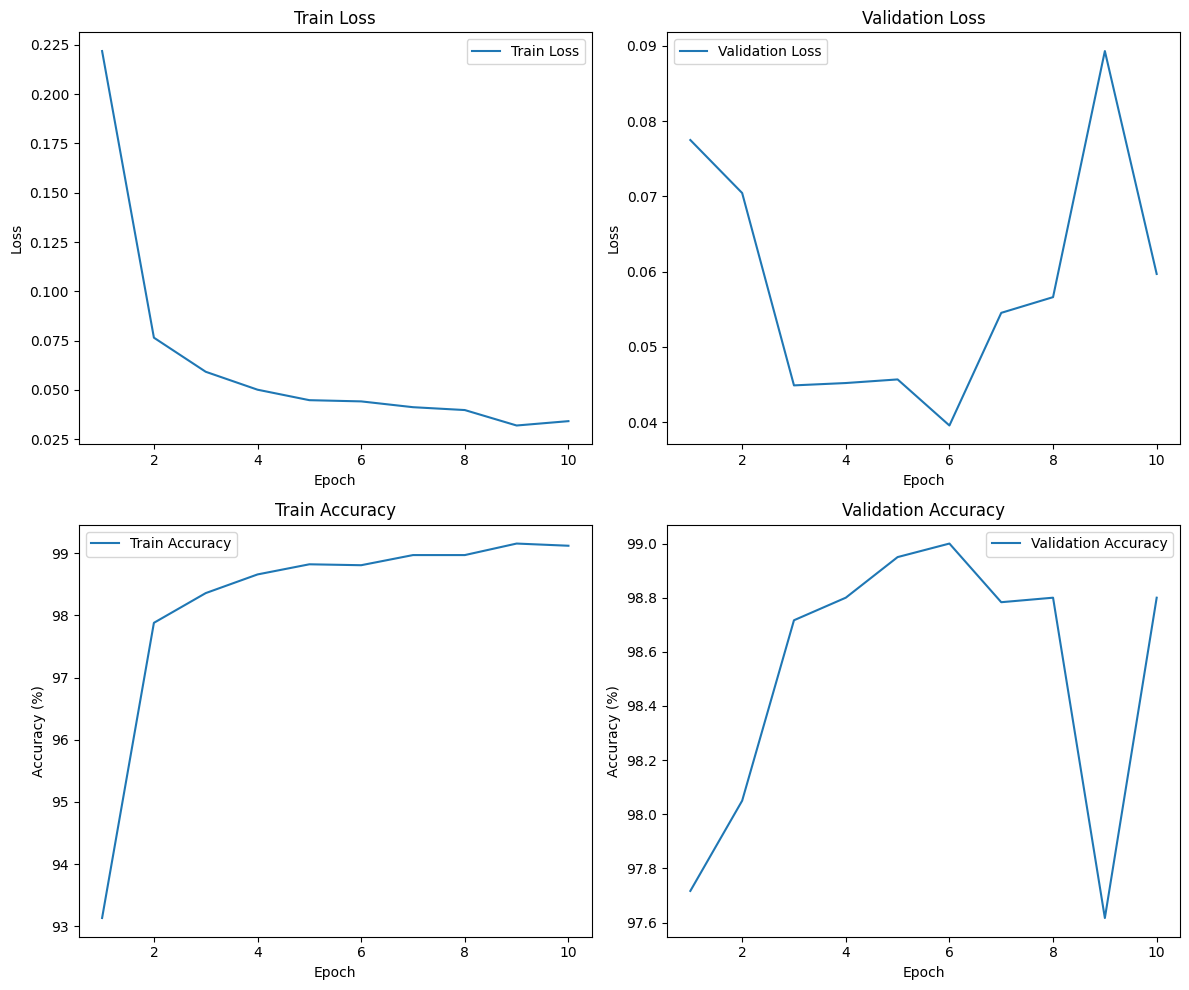

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from torchvision.models import googlenet

# Device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# QMNIST dataset (32x32 grayscale converted to 3-channel RGB)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Lambda(lambda img: img.convert("RGB")),  # Convert grayscale to RGB
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download dataset
full_dataset = torchvision.datasets.QMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.QMNIST(root='./data', train=False, download=True, transform=transform)

# Split training data into train and validation sets
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Load GoogleNet and adjust final layer
model = googlenet(num_classes=10, aux_logits=False)
model = model.to(device)

# Custom He + Orthogonal initialization
def custom_init(model):
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Linear):
            nn.init.orthogonal_(module.weight)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)

custom_init(model)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training and validation loop
num_epochs = 10
train_acc_list, val_acc_list = [], []
train_loss_list, val_loss_list = [], []

for epoch in range(num_epochs):
    model.train()
    correct, total = 0, 0
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    train_acc_list.append(train_accuracy)
    train_loss_list.append(running_train_loss / len(train_loader))

    # Validation
    model.eval()
    correct, total = 0, 0
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    val_acc_list.append(val_accuracy)
    val_loss_list.append(running_val_loss / len(val_loader))

    print(
        f'Epoch [{epoch + 1}/{num_epochs}], '
        f'Train Acc: {train_accuracy:.2f}%, Val Acc: {val_accuracy:.2f}%, '
        f'Train Loss: {train_loss_list[-1]:.4f}, Val Loss: {val_loss_list[-1]:.4f}'
    )

# Test accuracy
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f'\n✅ Final Test Accuracy on QMNIST: {test_accuracy:.2f}%')

# Plot loss and accuracy
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.plot(range(1, num_epochs + 1), train_loss_list, label='Train Loss')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(range(1, num_epochs + 1), val_loss_list, label='Validation Loss')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(range(1, num_epochs + 1), train_acc_list, label='Train Accuracy')
plt.title('Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(range(1, num_epochs + 1), val_acc_list, label='Validation Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()
